# 001 — Henry Hub Natural Gas Spot Price

**Source:** FRED series `DHHNGSP` via `fredapi`  
**File:** `data/raw/henry_hub_daily.csv`  
**Units:** USD per MMBtu  
**Frequency:** Daily (business days); weekends/holidays interpolated  
**Coverage:** 2000-01-01 to present

**Goal:** Understand the price history in isolation — distribution, volatility regimes, and key market events — before any cross-variable analysis.

In [9]:
from pathlib import Path

# Auto-detect repository root from current working directory.
project_root = Path.cwd().resolve()
if not (project_root / "data" / "raw").exists():
    for parent in [project_root, *project_root.parents]:
        if (parent / "data" / "raw").exists() and (parent / "notebooks").exists():
            project_root = parent
            break

print("Project root:", project_root)

Project root: C:\Users\alexd\Desktop\GIC\Prep\NatGasModel_US


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(context="paper", font_scale=2.0, style="whitegrid")

DIAG = project_root / "diagram" / "001_henry_hub_price"
DIAG.mkdir(parents=True, exist_ok=True)

## 1. Load & Inspect

In [8]:
df = pd.read_csv(project_root / "data" / "raw" / "henry_hub_daily.csv", index_col="date", parse_dates=True)
prices = df["henry_hub_price"].astype(float)

# Reindex to full calendar days and interpolate weekend/holiday gaps
full_idx = pd.date_range(start=prices.index.min(), end=prices.index.max(), freq="D")
prices = prices.reindex(full_idx).interpolate(method="time")
prices.index.name = "date"

print(f"Date range:  {prices.index.min().date()} → {prices.index.max().date()}")
print(f"Observations: {len(prices):,}")
print(f"Missing:      {prices.isna().sum()}")

Date range:  2000-01-03 → 2026-03-23
Observations: 9,577
Missing:      1


In [62]:
prices.to_frame().sample(5).sort_index()

,henry_hub_price
date,
2022-04-03,5.623333
2022-09-28,6.590000
2024-05-13,2.110000
2024-07-12,2.170000
2026-02-14,3.212500


In [63]:
prices.describe().round(2)

count    9576.00
mean        4.31
std         2.25
min         1.21
25%         2.77
50%         3.67
75%         5.36
max        30.72
Name: henry_hub_price, dtype: float64

## 2. Full Price History

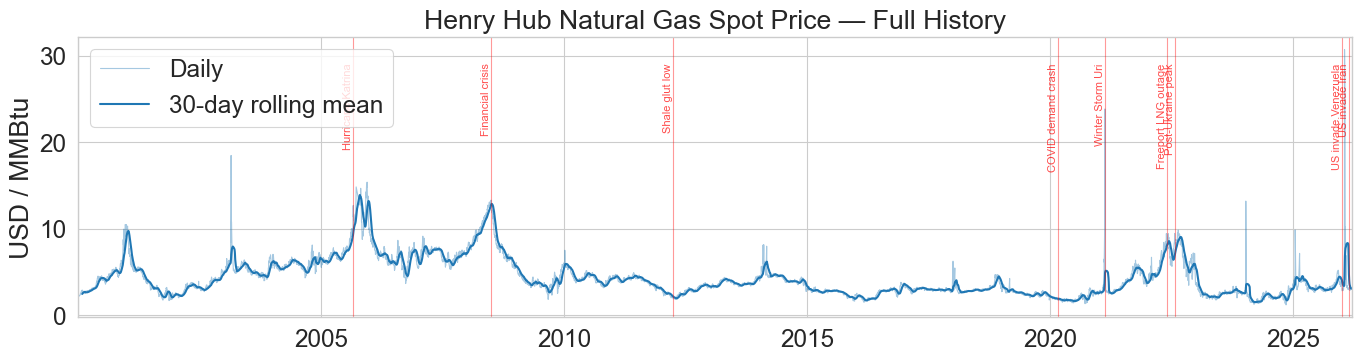

In [64]:
fig, ax = plt.subplots(figsize=(14, 4))

prices.plot(ax=ax, color="tab:blue", alpha=0.4, linewidth=0.8, label="Daily")
prices.rolling(30).mean().plot(ax=ax, color="tab:blue", linewidth=1.5, label="30-day rolling mean")

# Key market events
events = {
    "2005-09-01": "Hurricane Katrina",
    "2008-07-01": "Financial crisis",
    "2012-04-01": "Shale glut low",
    "2020-03-01": "COVID demand crash",
    "2021-02-15": "Winter Storm Uri",
    "2022-06-01": "Freeport LNG outage",
    "2022-08-01": "Post-Ukraine peak",
    "2026-01-03": "US invade Venezuela",
    "2026-02-28": "US invade Iran",
}

for date, label in events.items():
    ax.axvline(pd.Timestamp(date), color="red", alpha=0.4, linewidth=0.8)
    ax.annotate(
        label,
        xy=(pd.Timestamp(date), prices.max() * 0.95),
        fontsize=8,
        rotation=90,
        va="top",
        ha="right",
        color="red",
        alpha=0.7,
    )

ax.set_title("Henry Hub Natural Gas Spot Price — Full History")
ax.set_ylabel("USD / MMBtu")
ax.set_xlabel("")
ax.legend(loc="upper left")

fig.tight_layout()
fig.savefig(DIAG / "henry_hub_full_history.svg", format="svg", bbox_inches="tight")
plt.show()

## 3. Recent Period — 2020 to Present

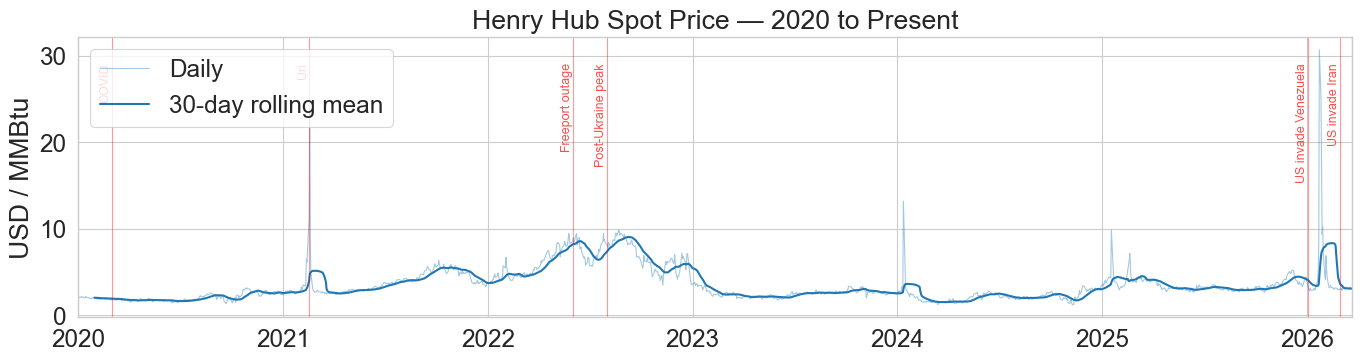

In [65]:
recent = prices["2020":]

fig, ax = plt.subplots(figsize=(14, 4))

recent.plot(ax=ax, color="tab:blue", alpha=0.4, linewidth=0.8, label="Daily")
recent.rolling(30).mean().plot(ax=ax, color="tab:blue", linewidth=1.5, label="30-day rolling mean")

recent_events = {
    "2020-03-01": "COVID",
    "2021-02-15": "Uri",
    "2022-06-01": "Freeport outage",
    "2022-08-01": "Post-Ukraine peak",
    "2026-01-03": "US invade Venezuela",
    "2026-02-28": "US invade Iran",
}

for date, label in recent_events.items():
    ax.axvline(pd.Timestamp(date), color="red", alpha=0.4, linewidth=0.8)
    ax.annotate(
        label,
        xy=(pd.Timestamp(date), recent.max() * 0.95),
        fontsize=9,
        rotation=90,
        va="top",
        ha="right",
        color="red",
        alpha=0.7,
    )

ax.set_title("Henry Hub Spot Price — 2020 to Present")
ax.set_ylabel("USD / MMBtu")
ax.set_xlabel("")
ax.legend(loc="upper left")

fig.tight_layout()
fig.savefig(DIAG / "henry_hub_recent_2020.svg", format="svg", bbox_inches="tight")
plt.show()

## 4. Volatility Regimes — Rolling Standard Deviation

Rolling 30-day standard deviation shows when the market was calm vs stressed. High volatility periods correspond to supply shocks and demand surprises — useful context for understanding where models are likely to underperform.

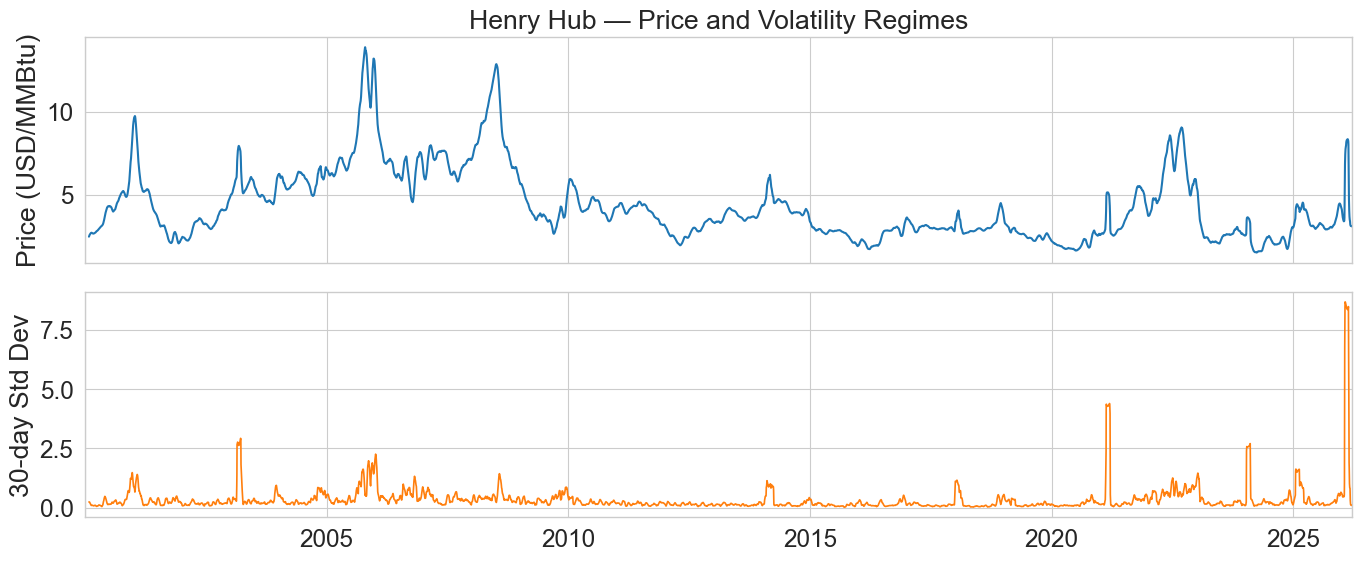

In [66]:
rolling_std = prices.rolling(30).std()

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

prices.rolling(30).mean().plot(ax=axes[0], color="tab:blue", linewidth=1.5)
axes[0].set_ylabel("Price (USD/MMBtu)")
axes[0].set_title("Henry Hub — Price and Volatility Regimes")

rolling_std.plot(ax=axes[1], color="tab:orange", linewidth=1.2)
axes[1].set_ylabel("30-day Std Dev")
axes[1].set_xlabel("")

fig.tight_layout()
fig.savefig(DIAG / "henry_hub_volatility_regimes.svg", format="svg", bbox_inches="tight")
plt.show()

## 5. Price Distribution

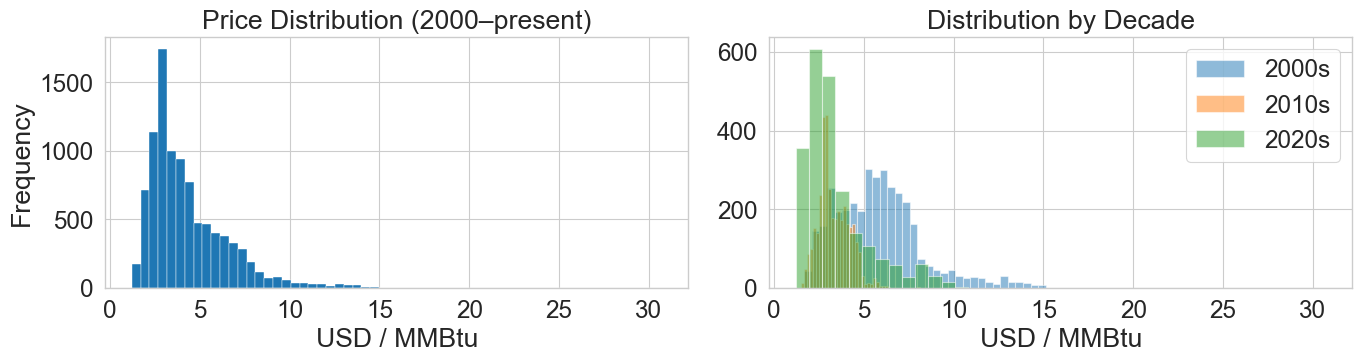

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
axes[0].hist(prices.dropna(), bins=60, color="tab:blue", edgecolor="white", linewidth=0.3)
axes[0].set_title("Price Distribution (2000–present)")
axes[0].set_xlabel("USD / MMBtu")
axes[0].set_ylabel("Frequency")

# By decade
price_2000s = prices["2000":"2009"].dropna()
price_2010s = prices["2010":"2019"].dropna()
price_2020s = prices["2020":].dropna()

axes[1].hist(price_2000s, bins=40, alpha=0.5, label="2000s", color="tab:blue")
axes[1].hist(price_2010s, bins=40, alpha=0.5, label="2010s", color="tab:orange")
axes[1].hist(price_2020s, bins=40, alpha=0.5, label="2020s", color="tab:green")
axes[1].set_title("Distribution by Decade")
axes[1].set_xlabel("USD / MMBtu")
axes[1].legend()

fig.tight_layout()
fig.savefig(DIAG / "henry_hub_distribution.svg", format="svg", bbox_inches="tight")
plt.show()

## 6. Observations

### Price regimes visible in the data

- **2000–2008:** High and volatile — pre-shale era, gas supply was constrained by conventional drilling, and the market had no buffer against weather or hurricane disruptions. Katrina (2005) knocked out Gulf of Mexico production and sent prices to ~$15/MMBtu, briefly
- **2009–2020:** Structurally lower — the shale revolution (Marcellus, Haynesville, Permian associated gas) flooded the market with cheap supply. Prices collapsed into a $2–4 range that the market came to treat as "normal." Gas went from a scarce fuel to an abundant one in roughly 5 years
- **2021–2022:** The first sustained break above the shale range. Two distinct drivers:
  - *Winter Storm Uri (Feb 2021):* A 1-week weather event — wellheads froze across Texas and Oklahoma, supply collapsed while heating demand spiked. The daily spot hit **$30.72/MMBtu** — the highest print in 20+ years. The spike was sharp and brief: prices returned to $2.50 within weeks. Classic supply shock, not a structural shift
  - *2022 Ukraine/LNG cycle:* A structural move, not a weather event. European buyers pulled US LNG exports to replace Russian pipeline gas. US export capacity was near full utilisation (~14 Bcf/day), effectively creating a new inelastic demand floor. Henry Hub traded above $8 for months. The Freeport LNG outage (June 2022) then briefly reversed this by freeing up ~2 Bcf/day of domestic supply — a rare example of bearish news in a bull market
- **2023–present:** Reversion toward the shale range ($2–3.50). LNG contracts are re-priced, export capacity roughly matched to production growth

---

### Distribution characteristics

The price series is **right-skewed** (mean $4.31 vs median $3.67 — mean pulled up by tail events), with a long right tail and a practical floor near $1.50–2.00:

- **Downside floor:** ~$1.50–2.00/MMBtu reflects the economics of the lowest-cost shale producers (Haynesville, Appalachian gas). Below this level, rigs are stacked and supply falls. The market has self-correcting behaviour on the downside — price discovery finds a floor
- **Upside is unbounded:** Supply shocks can send Henry Hub to $10, $15, or even $30 for brief windows. The distribution is fat-tailed on the right. This asymmetry matters for options pricing and risk management
- **75th percentile: $5.36 — meaning 75% of trading days since 2000 have been below $5.36.** A trader quoting "gas at $8" would be positioned in the top quartile of the full historical range

---

### Event-driven vs structural moves

A key distinction for a gas trader — and for model calibration:

| Move type | Example | Duration | Recovery |
|---|---|---|---|
| Weather shock | Uri (Feb 2021) | Days–weeks | Rapid snap-back |
| Supply disruption | Freeport outage (Jun 2022) | Weeks–months | Gradual |
| Structural regime shift | Shale revolution (2009) | Years | No reversion |
| External demand shock | Ukraine/LNG (2022) | Months | Partial reversion |

Models trained on calm periods (e.g. 2015–2019) will fail on shock events — Uri would have been unforecastable from fundamentals alone.

---

### Volatility regimes — trading implication

High 30-day realised volatility periods correspond to:
1. **Supply shocks** — wellhead freeze-offs, hurricane disruptions, pipeline outages
2. **Storage extremes** — either record-low entering winter (bullish) or record-high (bearish)
3. **External demand surprises** — LNG curtailments, geopolitical events

For this model: **volatility regimes are where forecast errors will be largest.** The static regressors scenario (prices frozen at last known) will be most wrong precisely when prices are moving fastest — which is exactly when a real forecaster is operating under the most uncertainty.

---

### Henry Hub-specific market structure

- **Settlement point for NYMEX front-month futures** — every physical gas trade in the US is priced relative to Henry Hub. Even if you trade Appalachian or Permian gas, you are trading a *basis differential* against HH
- **Thursday EIA storage report** is the dominant intraweek price driver. A storage "surprise" (actual vs analyst consensus) can move Henry Hub 3–5%+ within minutes of the 10:30am ET release. Weekly storage is the market's primary signal for supply health
- **The 5-year average storage comparison** is the market's compass: entering November above the 5-year average is bearish (plenty of gas in the ground for winter); below is bullish. Price and this single metric are tightly correlated in the Oct–Nov pre-winter window
- **Front-month vs 12-month strip:** The daily spot (what we are modelling) is more volatile than the 12-month forward strip. Futures markets price in seasonal structure — the strip captures "expected" seasonality, the spot reflects actual conditions. Basis between spot and strip widens during shocks

---

### Trading context

The 2010s low-price regime reflects the structural shift from gas scarcity to gas abundance driven by shale. The 2022 spike is the first sustained break above that range — driven by an external demand shock (Europe pulling US LNG exports) rather than domestic supply constraints.

Understanding which **regime** we are in matters for model calibration — a model trained only on 2010–2020 data would have had no basis to forecast 2022 prices, and a model trained on 2000–2008 would over-estimate "normal" prices by 2x.

The **2026 geopolitical events** (annotated in the charts) represent a different category of risk again: supply-side shocks from US military action affecting major gas-producing or LNG-transit regions. These are not forecastable from fundamentals — they appear as structural breaks in the series.